# LookBench Model Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SerendipityOneInc/look-bench/blob/main/notebooks/02_model_evaluation.ipynb)

This notebook demonstrates how to perform **complete model evaluation** on the LookBench dataset with all metrics.

We'll evaluate models using:
- **Recall@K** (K=1, 5, 10, 20)
- **MRR** (Mean Reciprocal Rank)
- **NDCG@5** (Normalized Discounted Cumulative Gain)
- **mAP** (Mean Average Precision)

📄 **Paper**: [arxiv.org/abs/2601.14706](https://arxiv.org/abs/2601.14706)

## Setup

In [1]:
import sys
import os

# Add the repo root to sys.path so manager.py, metrics/, etc. are importable
repo_root = r"C:/Users/i_am_fuch/Desktop/look-bench"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

os.chdir(repo_root)  # also set working directory to repo root

In [2]:
import torch
import numpy as np
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt

from manager import ConfigManager, ModelManager
from metrics import RankEvaluator, MRREvaluator, NDCGEvaluator, MAPEvaluator

print("✅ Imports successful!")

c:\Users\i_am_fuch\Desktop\look-bench\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-21 19:42:54.288 - models.registry - INFO - Model successfully registered
Data: {
  "model_name": "clip",
  "model_type": "clip",
  "model_class": "CLIPEmbeddingModel"
}
2026-05-21 19:42:54.302 - models.registry - INFO - Model successfully registered
Data: {
  "model_name": "siglip",
  "model_type": "siglip",
  "model_class": "SigLIPEmbeddingModel"
}
2026-05-21 19:42:54.304 - models.registry - INFO - Model successfully registered
Data: {
  "model_name": "dinov2",
  "model_type": "dinov2",
  "model_class": "DINOv2EmbeddingModel"
}
2026-05-21 19:42:54.318 - models.registry - INFO - Model successfully registered
Data: {
  "model_name": "gr-lite",
  "model_type": "gr-lite",
  "model_class": "GRLiteModel"
}
2026-05-21 19:42:54.324 - lookbench_datasets.registry - INFO - Dataset successfully registered
Data: {
  "dataset_name": "fashion200k",
  "metadata": {
    "description": "Fashion200K dataset for fashion image retrieval",
    "num_categories": 200000,
    "tasks": [
      "image_r

## Load LookBench Dataset

Choose which subset to evaluate:
- `real_studio_flat` - Easy: single-item retrieval
- `aigen_studio` - Medium: AI-generated studio images
- `real_streetlook` - Hard: multi-item outfit retrieval
- `aigen_streetlook` - Hard: AI-generated street looks

In [3]:
# Chọn subset muốn evaluate
subset_name = 'real_studio_flat'  # thay đổi ở đây thôi

# Load đúng config đó
print("Loading LookBench dataset...")
dataset = load_dataset("srpone/look-bench", subset_name)

# Access trực tiếp, không cần [subset_name] nữa
query_data = dataset['query']
gallery_data = dataset['gallery']

print(f"\n✅ Evaluating on: {subset_name}")
print(f"   Query samples: {len(query_data)}")
print(f"   Gallery samples: {len(gallery_data)}")

Loading LookBench dataset...

✅ Evaluating on: real_studio_flat
   Query samples: 1011
   Gallery samples: 3951


## Load Model

Available models: `clip`, `siglip`, `dinov2`

In [4]:
# Initialize managers
config_manager = ConfigManager('configs/config.yaml')
model_manager = ModelManager(config_manager)

# Choose model to evaluate
model_name = 'gr-lite'  # Change to 'siglip' or 'dinov2' to test other models

# Load model
print(f"Loading {model_name} model...")
model, model_wrapper = model_manager.load_model(model_name)
transform = model_manager.get_transform(model_name)

model.eval()
if torch.cuda.is_available():
    model = model.cuda()
    print("✅ Model moved to CUDA")
else:
    print("⚠️ Running on CPU (slower)")

print(f"✅ Model loaded: {model_name}")

2026-05-21 19:42:59.369 - manager - INFO - Configuration loaded successfully
Data: {
  "config_path": "configs/config.yaml",
  "config_keys": [
    "global",
    "logging",
    "datasets",
    "pipeline",
    "evaluation",
    "clip",
    "siglip",
    "dinov2",
    "gr-lite",
    "custom_model"
  ]
}
2026-05-21 19:42:59.372 - manager - INFO - Cache directories configured
Data: {
  "cache_dir": "C:\\Users\\i_am_fuch/.cache"
}
Loading gr-lite model...
2026-05-21 19:42:59.375 - manager - INFO - Loading model
Data: {
  "model_name": "gr-lite",
  "model_config": {
    "enabled": true,
    "model_name": "srpone/gr-lite",
    "model_path": null,
    "input_size": 518,
    "embedding_dim": 256,
    "device": "cuda"
  }
}
2026-05-21 19:42:59.376 - models.factory - INFO - Creating model
Data: {
  "model_type": "gr-lite",
  "model_name": "srpone/gr-lite",
  "model_path": null
}
2026-05-21 19:42:59.379 - models.grlite_model - INFO - Loading GR-Lite model
Data: {
  "model_name": "srpone/gr-lite",


## Extract Features

This may take a few minutes depending on dataset size and GPU availability.

In [7]:
def extract_features_from_dataset(data, model, transform, batch_size=32):
    features = []
    labels = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(data), batch_size), desc="Extracting features"):
            batch_data = data[i:i+batch_size]  # dict of lists
            
            images = batch_data['image']
            batch_labels = batch_data.get('item_ID', list(range(i, i+len(images))))
            
            batch_images = [transform(img) for img in images]
            batch_tensor = torch.stack(batch_images)
            
            if torch.cuda.is_available():
                batch_tensor = batch_tensor.cuda()
            
            batch_features = model(batch_tensor)
            features.append(batch_features.cpu())
            labels.extend(batch_labels)
    
    features = torch.cat(features, dim=0)
    return features.numpy(), np.array(labels)

# Extract features
print("\n📊 Extracting query features...")
query_features, query_labels = extract_features_from_dataset(query_data.select(range(100)), model, transform)

gallery_features, gallery_labels = extract_features_from_dataset(
    gallery_data.select(range(100)), model, transform
)

print(f"\n✅ Feature extraction complete!")
print(f"   Query features shape: {query_features.shape}")
print(f"   Gallery features shape: {gallery_features.shape}")


📊 Extracting query features...


Extracting features: 100%|██████████| 4/4 [02:55<00:00, 43.88s/it]


✅ Feature extraction complete!
   Query features shape: (100, 1024)
   Gallery features shape: (100, 1024)


## L2 Normalization

Normalize features for cosine similarity computation.

In [8]:
# L2 normalize features
query_features = query_features / np.linalg.norm(query_features, axis=1, keepdims=True)
gallery_features = gallery_features / np.linalg.norm(gallery_features, axis=1, keepdims=True)

print("✅ Features normalized")

✅ Features normalized


## Compute Similarity Matrix

In [9]:
# Compute cosine similarity
similarity_matrix = np.dot(query_features, gallery_features.T)
sorted_indices = np.argsort(-similarity_matrix, axis=1)

print(f"✅ Similarity matrix computed")
print(f"   Shape: {similarity_matrix.shape}")
print(f"   Range: [{similarity_matrix.min():.4f}, {similarity_matrix.max():.4f}]")

✅ Similarity matrix computed
   Shape: (100, 100)
   Range: [-0.0323, 0.9322]


## Evaluate with All Metrics

Computing Recall@K, MRR, NDCG@5, and mAP...

In [14]:
# Initialize evaluators
rank_evaluator = RankEvaluator(rank_values=[1, 5, 10, 20])
mrr_evaluator = MRREvaluator()
ndcg_evaluator = NDCGEvaluator(rank_values=[5])
map_evaluator = MAPEvaluator()

results = {}

# Recall@K
print("Computing Recall@K...")
for k in [1, 5, 10, 20]:
    scores = []
    for i in range(len(query_labels)):
        score = rank_evaluator.metric_eval(
            sorted_indices[i],
            k,
            query_labels[i],
            gallery_labels
        )
        scores.append(score)
    results[f'Recall@{k}'] = np.mean(scores) * 100

# MRR
print("Computing MRR...")
mrr_scores = []
for i in range(len(query_labels)):
    score = mrr_evaluator.metric_eval(
        sorted_indices[i],
        5,
        query_labels[i],
        gallery_labels
    )
    mrr_scores.append(score)
results['MRR'] = np.mean(mrr_scores) * 100

# NDCG@5
print("Computing NDCG@5...")
ndcg_scores = []
for i in range(len(query_labels)):
    score = ndcg_evaluator.metric_eval(
        sorted_indices[i],
        5,
        query_labels[i],
        gallery_labels
    )
    ndcg_scores.append(score)
results['NDCG@5'] = np.mean(ndcg_scores) * 100

# mAP
print("Computing mAP...")
map_scores = []
for i in range(len(query_labels)):
    score = map_evaluator.metric_eval(
        sorted_indices[i],
        5,
        query_labels[i],
        gallery_labels
    )
    map_scores.append(score)
results['mAP'] = np.mean(map_scores) * 100

print("\n✅ All metrics computed!")

Computing Recall@K...
Computing MRR...
Computing NDCG@5...
Computing mAP...

✅ All metrics computed!


## Results

In [15]:
# Print results
print(f"\n{'='*60}")
print(f"Evaluation Results on {subset_name}")
print(f"Model: {model_name}")
print(f"{'='*60}")
for metric, value in results.items():
    print(f"{metric:15s}: {value:6.2f}%")
print(f"{'='*60}")


Evaluation Results on real_studio_flat
Model: gr-lite
Recall@1       :  17.00%
Recall@5       :  23.00%
Recall@10      :  23.00%
Recall@20      :  24.00%
MRR            :  19.67%
NDCG@5         :  17.28%
mAP            :  15.37%


## Visualize Top Retrievals

Let's visualize some retrieval results to understand model performance.

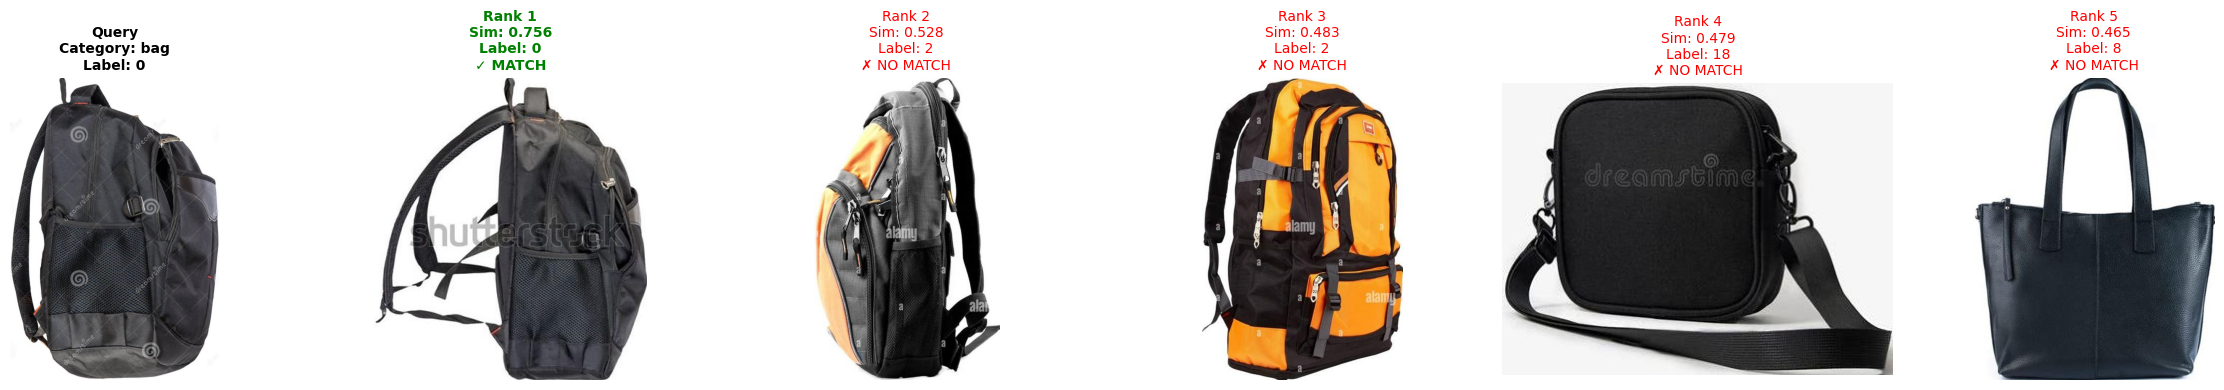

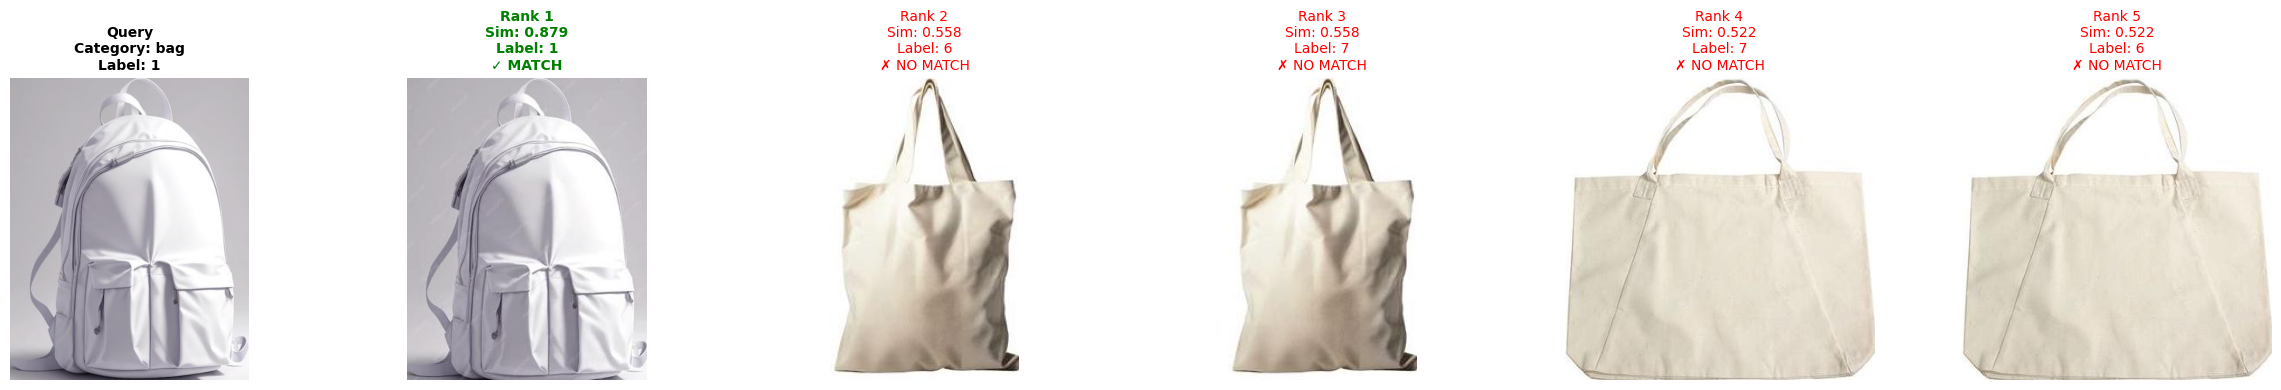

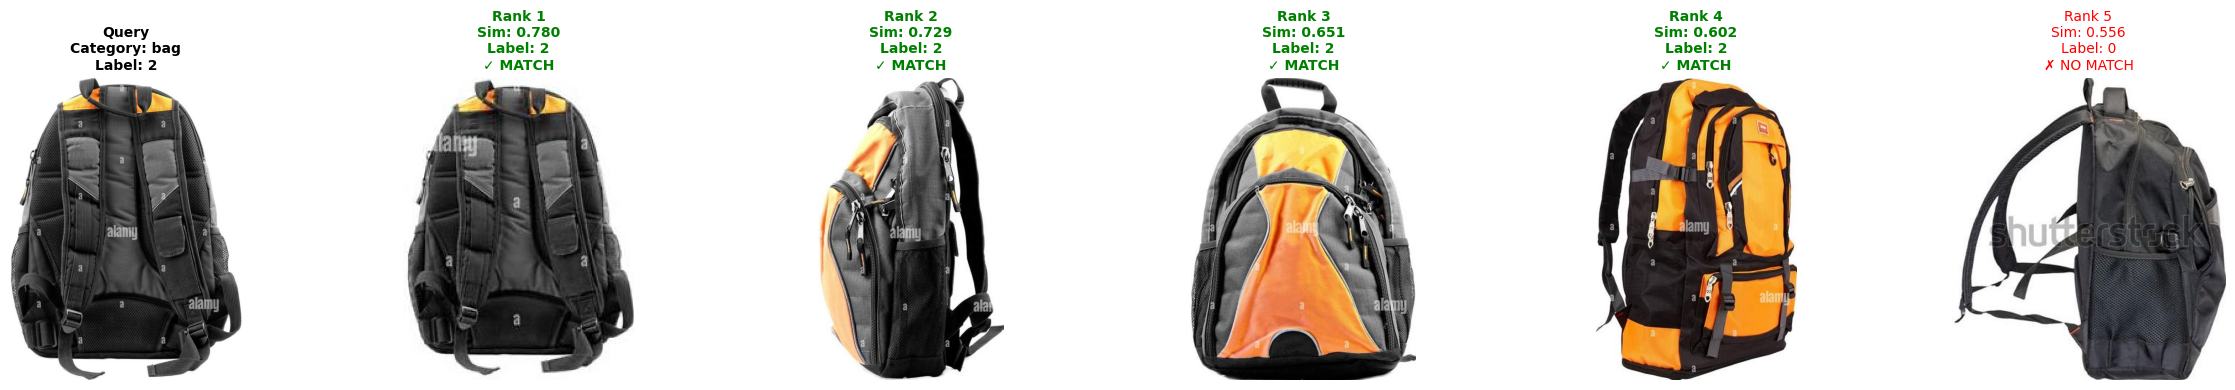

In [16]:
def visualize_retrieval(query_idx, top_k=5):
    """Visualize top-k retrievals for a query"""
    query_sample = query_data[query_idx]
    top_indices = sorted_indices[query_idx][:top_k]
    
    fig, axes = plt.subplots(1, top_k + 1, figsize=(4 * (top_k + 1), 4))
    
    # Show query
    axes[0].imshow(query_sample['image'])
    axes[0].set_title('Query\n' + f"Category: {query_sample.get('category', 'N/A')}\n" +
                     f"Label: {query_labels[query_idx]}", 
                     fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Show top retrievals
    for i, gallery_idx in enumerate(top_indices):
        gallery_sample = gallery_data[gallery_idx]
        sim = similarity_matrix[query_idx, gallery_idx]
        match = gallery_labels[gallery_idx] == query_labels[query_idx]
        
        axes[i + 1].imshow(gallery_sample['image'])
        title = f"Rank {i+1}\nSim: {sim:.3f}\nLabel: {gallery_labels[gallery_idx]}"
        if match:
            title += "\n✓ MATCH"
            axes[i + 1].set_title(title, fontsize=10, color='green', fontweight='bold')
        else:
            title += "\n✗ NO MATCH"
            axes[i + 1].set_title(title, fontsize=10, color='red')
        axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize a few examples
for i in range(min(3, len(query_data))):
    visualize_retrieval(i, top_k=5)

## Evaluate on Multiple Subsets (Optional)

Uncomment and run this cell to evaluate on all LookBench subsets.

In [ ]:
# # Evaluate on all subsets
# all_results = {}
# subsets = ['real_studio_flat', 'aigen_studio', 'real_streetlook', 'aigen_streetlook']
# 
# for subset in subsets:
#     print(f"\n{'='*60}")
#     print(f"Evaluating on {subset}...")
#     print(f"{'='*60}")
#     
#     # Load subset
#     query_data_sub = dataset[subset]['query']
#     gallery_data_sub = dataset[subset]['gallery']
#     
#     # Extract features and evaluate
#     # ... (copy the feature extraction and evaluation code here)
#     
#     all_results[subset] = results
# 
# # Print summary
# import pandas as pd
# df = pd.DataFrame(all_results).T
# print("\n" + "="*60)
# print("Summary Across All Subsets")
# print("="*60)
# print(df)

## Next Steps

1. **Try different models**: Change `model_name` to 'siglip' or 'dinov2'
2. **Evaluate other subsets**: Change `subset_name` to test different difficulty levels
3. **Integrate custom models**: See `03_custom_model.ipynb`
4. **Fine-tune models**: Use LookBench for model training and evaluation

### Useful Links

- 📄 **Paper**: https://arxiv.org/abs/2601.14706
- 🏠 **Project**: https://serendipityoneinc.github.io/look-bench-page/
- 🤗 **Dataset**: https://huggingface.co/datasets/srpone/look-bench
- 💻 **GitHub**: https://github.com/SerendipityOneInc/look-bench